In [ ]:

%pip install -q transformers datasets torch torchvision torchaudio matplotlib seaborn scikit-learn tqdm pandas numpy beautifulsoup4
%pip uninstall -y torch-xla

# Mount Drive
#from google.colab import drive
#drive.mount('/content/drive')

import sys
import os
import json
import pandas as pd
import numpy as np
import torch
from torch.utils.data import DataLoader
from transformers import RobertaTokenizer, RobertaForSequenceClassification
from torch.optim import AdamW

from transformers import get_linear_schedule_with_warmup
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from pathlib import Path

# Add your project to path
#sys.path.append('C:/Child Guardian GP2/child guardian code')
PROJECT_ROOT = Path().resolve().parent  # if notebook is in notebooks/

# Add project root to Python path
sys.path.append(str(PROJECT_ROOT))
# Import your custom modules
from core.training import ChatDataset, train_epoch, evaluate, save_model

# Setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Paths
DATA_PATH = os.getenv('DATA_PATH')
MODEL_PATH = os.getenv('MODEL_PATH')
os.makedirs(MODEL_PATH, exist_ok=True)

# Load your cleaned data from Drive
print("Loading datasets from Drive...")
train_df = pd.read_csv(f'{DATA_PATH}/predator_train_cleaned.csv')
valid_df = pd.read_csv(f'{DATA_PATH}/predator_valid_cleaned.csv')
test_df = pd.read_csv(f'{DATA_PATH}/predator_test_cleaned.csv')

# Make sure we're using the cleaned text column
# (adjust column name if yours is different)
text_column = 'text_clean' if 'text_clean' in train_df.columns else 'text'

print(f"\nTrain: {train_df.shape}, Predators: {train_df['label'].sum()}")
print(f"Valid: {valid_df.shape}, Predators: {valid_df['label'].sum()}")
print(f"Test: {test_df.shape}, Predators: {test_df['label'].sum()}")

# Check class balance
print("\nClass distribution:")
print("Train:", train_df['label'].value_counts().to_dict())
print("Valid:", valid_df['label'].value_counts().to_dict())
print("Test:", test_df['label'].value_counts().to_dict())

# Initialize tokenizer
print("\nLoading RoBERTa tokenizer...")
tokenizer = RobertaTokenizer.from_pretrained('roberta-base')

# Create datasets
print("Creating datasets...")
train_dataset = ChatDataset(
    train_df[text_column].values,
    train_df['label'].values,
    tokenizer
)
valid_dataset = ChatDataset(
    valid_df[text_column].values,
    valid_df['label'].values,
    tokenizer
)
test_dataset = ChatDataset(
    test_df[text_column].values,
    test_df['label'].values,
    tokenizer
)

# Create dataloaders
batch_size = 16
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)



Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.
Using device: cuda
Loading datasets from Drive...

Train: (12988, 6), Predators: 1741
Valid: (1644, 6), Predators: 228
Test: (1649, 6), Predators: 224

Class distribution:
Train: {0: 11247, 1: 1741}
Valid: {0: 1416, 1: 228}
Test: {0: 1425, 1: 224}

Loading RoBERTa tokenizer...
Creating datasets...



Creating balanced batch sampler...

Initializing RoBERTa model...


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



STARTING TRAINING WITH BALANCED BATCHES

Epoch 1/5


Validating: 100%|██████████| 103/103 [00:26<00:00,  3.89it/s]

...

✓ Saved best model to Drive (val_f1=0.9824)

Loading best model for evaluation...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


TEST SET EVALUATION


Testing: 100%|██████████| 104/104 [00:20<00:00,  4.97it/s]



Test Accuracy: 0.9745
Test F1: 0.9746

Classification Report:
              precision    recall  f1-score   support

      Normal       0.99      0.98      0.99      1425
    Predator       0.90      0.91      0.91       224

    accuracy                           0.97      1649
   macro avg       0.94      0.95      0.95      1649
weighted avg       0.97      0.97      0.97      1649



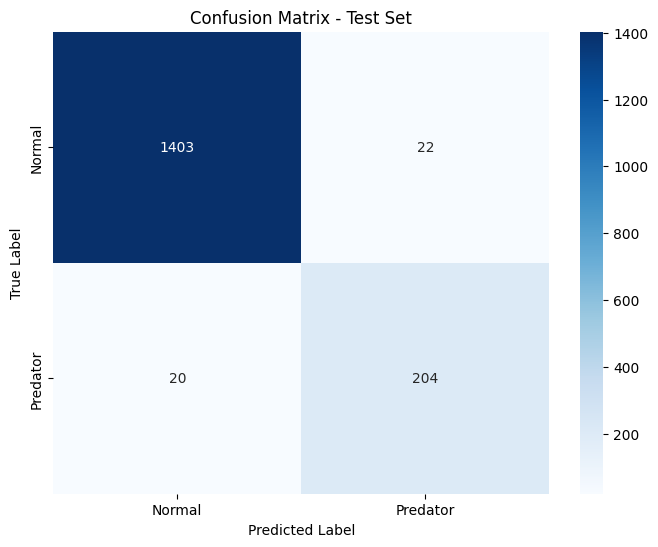


✅ All results saved to Drive: C:/Child Guardian GP2/models/predator_roberta
   - Model: C:/Child Guardian GP2/models/predator_roberta/best_model
   - Confusion matrix: C:/Child Guardian GP2/models/predator_roberta/confusion_matrix.png
   - Test results: C:/Child Guardian GP2/models/predator_roberta/test_results.json
   - Training history: C:/Child Guardian GP2/models/predator_roberta/training_history.json

TESTING INFERENCE EXAMPLES

Text: Hey, how old are you? What's your asl?
Prediction: Normal (confidence: 1.000)

Text: I love playing video games, wanna play together?
Prediction: Normal (confidence: 1.000)

Text: You're so cute, send me pics
Prediction: Predator (confidence: 1.000)

Text: Can you help me with my homework?
Prediction: Normal (confidence: 1.000)


In [ ]:


from torch.utils.data import WeightedRandomSampler
from sklearn.metrics import f1_score, confusion_matrix, classification_report

epochs = 5 # Define epochs here

# Create stratified sampler for balanced batches
print("\nCreating balanced batch sampler...")
labels = train_df['label'].values

# Calculate weights for each sample (inverse of class frequency)
class_counts = np.bincount(labels)
class_weights = 1.0 / class_counts
sample_weights = [class_weights[label] for label in labels]

# Create sampler that ensures each batch has balanced classes
sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

# Replace train_loader with balanced version
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    sampler=sampler,
    num_workers=2
)

# Initialize model (ONLY ONCE)
print("\nInitializing RoBERTa model...")
model = RobertaForSequenceClassification.from_pretrained(
    'roberta-base',
    num_labels=2
).to(device)

# Optimizer with slightly higher learning rate
optimizer = AdamW(model.parameters(), lr=3e-5)
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * len(train_loader) * epochs),
    num_training_steps=len(train_loader) * epochs
)


# Training loop
print("\n" + "="*60)
print("STARTING TRAINING WITH BALANCED BATCHES")
print("="*60)

train_losses = []
val_f1_scores = []
best_val_f1 = 0

for epoch in range(epochs):
    print(f"\n{'='*50}")
    print(f"Epoch {epoch + 1}/{epochs}")
    print('='*50)

    # Training
    model.train()
    total_loss = 0
    train_preds = []
    train_labels_list = []

    progress_bar = tqdm(train_loader, desc="Training")
    for batch in progress_bar:
        optimizer.zero_grad()

        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()

        # Track predictions
        preds = torch.argmax(outputs.logits, dim=-1)
        train_preds.extend(preds.cpu().numpy())
        train_labels_list.extend(labels.cpu().numpy())

        # Update progress bar
        progress_bar.set_postfix({'loss': f'{loss.item():.4f}'})

    avg_train_loss = total_loss / len(train_loader)
    train_acc = (np.array(train_preds) == np.array(train_labels_list)).mean()

    # Validation
    model.eval()
    val_preds = []
    val_labels_list = []
    val_loss = 0

    with torch.no_grad():
        for batch in tqdm(valid_loader, desc="Validating"):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
            val_loss += outputs.loss.item()

            preds = torch.argmax(outputs.logits, dim=-1)
            val_preds.extend(preds.cpu().numpy())
            val_labels_list.extend(labels.cpu().numpy())

    avg_val_loss = val_loss / len(valid_loader)
    val_acc = (np.array(val_preds) == np.array(val_labels_list)).mean()
    val_f1 = f1_score(val_labels_list, val_preds, average='weighted')

    # Store metrics
    train_losses.append(avg_train_loss)
    val_f1_scores.append(val_f1)

    # Print metrics
    print(f"\nTrain Loss: {avg_train_loss:.4f}, Train Acc: {train_acc:.4f}")
    print(f"Val Loss: {avg_val_loss:.4f}, Val Acc: {val_acc:.4f}, Val F1: {val_f1:.4f}")

    # Confusion matrix for validation
    cm = confusion_matrix(val_labels_list, val_preds)
    print(f"\nValidation Confusion Matrix:")
    if cm.size == 4:
        print(f"  TN: {cm[0,0]}  FP: {cm[0,1]}")
        print(f"  FN: {cm[1,0]}  TP: {cm[1,1]}")
    else:
        print(cm)

    # Save best model based on F1 score (better for imbalanced data)
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        model.save_pretrained(f"{MODEL_PATH}/best_model")
        tokenizer.save_pretrained(f"{MODEL_PATH}/best_model")
        print(f"✓ Saved best model to Drive (val_f1={val_f1:.4f})")

# Load best model for testing
print("\nLoading best model for evaluation...")
model = RobertaForSequenceClassification.from_pretrained(f"{MODEL_PATH}/best_model").to(device)
tokenizer = RobertaTokenizer.from_pretrained(f"{MODEL_PATH}/best_model")

# Final evaluation on test set
print("\n" + "="*60)
print("TEST SET EVALUATION")
print("="*60)

model.eval()
test_preds = []
test_labels_list = []

with torch.no_grad():
    for batch in tqdm(test_loader, desc="Testing"):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids, attention_mask=attention_mask)
        preds = torch.argmax(outputs.logits, dim=-1)

        test_preds.extend(preds.cpu().numpy())
        test_labels_list.extend(labels.cpu().numpy())

# Calculate test metrics
test_acc = (np.array(test_preds) == np.array(test_labels_list)).mean()
test_f1 = f1_score(test_labels_list, test_preds, average='weighted')

print(f"\nTest Accuracy: {test_acc:.4f}")
print(f"Test F1: {test_f1:.4f}")

# Classification report
print("\nClassification Report:")
print(classification_report(test_labels_list, test_preds, target_names=['Normal', 'Predator']))

# Confusion matrix
cm = confusion_matrix(test_labels_list, test_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Predator'],
            yticklabels=['Normal', 'Predator'])
plt.title('Confusion Matrix - Test Set')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.savefig(f'{MODEL_PATH}/confusion_matrix.png')
plt.show()

# Save test results to Drive
results = {
    'test_accuracy': float(test_acc),
    'test_f1': float(test_f1),
    'confusion_matrix': cm.tolist(),
    'classification_report': classification_report(test_labels_list, test_preds, output_dict=True),
    'model_path': MODEL_PATH,
    'data_path': DATA_PATH
}

with open(f'{MODEL_PATH}/test_results.json', 'w') as f:
    json.dump(results, f, indent=2)

# Save training history
history = {
    'train_loss': train_losses,
    'val_f1': val_f1_scores,
    'best_val_f1': best_val_f1
}

with open(f'{MODEL_PATH}/training_history.json', 'w') as f:
    json.dump(history, f, indent=2)

print(f"\n✅ All results saved to Drive: {MODEL_PATH}")
print(f"   - Model: {MODEL_PATH}/best_model")
print(f"   - Confusion matrix: {MODEL_PATH}/confusion_matrix.png")
print(f"   - Test results: {MODEL_PATH}/test_results.json")
print(f"   - Training history: {MODEL_PATH}/training_history.json")

# Quick inference examples
print("\n" + "="*60)
print("TESTING INFERENCE EXAMPLES")
print("="*60)

def predict_text(text, model, tokenizer, device):
    model.eval()
    encoding = tokenizer(
        text,
        truncation=True,
        padding='max_length',
        max_length=512,
        return_tensors='pt'
    ).to(device)

    with torch.no_grad():
        outputs = model(**encoding)
        pred = torch.argmax(outputs.logits, dim=-1).item()
        prob = torch.softmax(outputs.logits, dim=-1)[0].cpu().numpy()

    return {
        'prediction': 'Predator' if pred == 1 else 'Normal',
        'confidence': float(prob[pred]),
        'probabilities': {'Normal': float(prob[0]), 'Predator': float(prob[1])}
    }

test_texts = [
    "Hey, how old are you? What's your asl?",
    "I love playing video games, wanna play together?",
    "You're so cute, send me pics",
    "Can you help me with my homework?"
]

for text in test_texts:
    result = predict_text(text, model, tokenizer, device)
    print(f"\nText: {text}")
    print(f"Prediction: {result['prediction']} (confidence: {result['confidence']:.3f})")

In [ ]:
result1 = predict_text("Wanna call me", model, tokenizer, device)
print(f"Prediction: {result1['prediction']} (confidence: {result1['confidence']:.3f})")

Prediction: Predator (confidence: 1.000)
